Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('thesisGraph', false)"


--- Successfully connected to the Neo4j database. ---

--- Running Thesis Hypothesis Test ---
1. Projecting graph into GDS...
2. Generating node embeddings with FastRP and writing back to nodes...
   ✓ Created embeddings for 357 nodes
3. Fetching embeddings for correlation analysis...

--- HYPOTHESIS TEST RESULTS ---
Cosine Similarity between an Early and a Late-Stage Attacker Node: 1.0000
Result: High correlation found. The hypothesis is strongly supported.

--- Verifying Attack Paths ---
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 143.88.15.10 -> 143.88.1.18 on port 20 (Tactic: Reconnaissance)
Attack Detected: 14

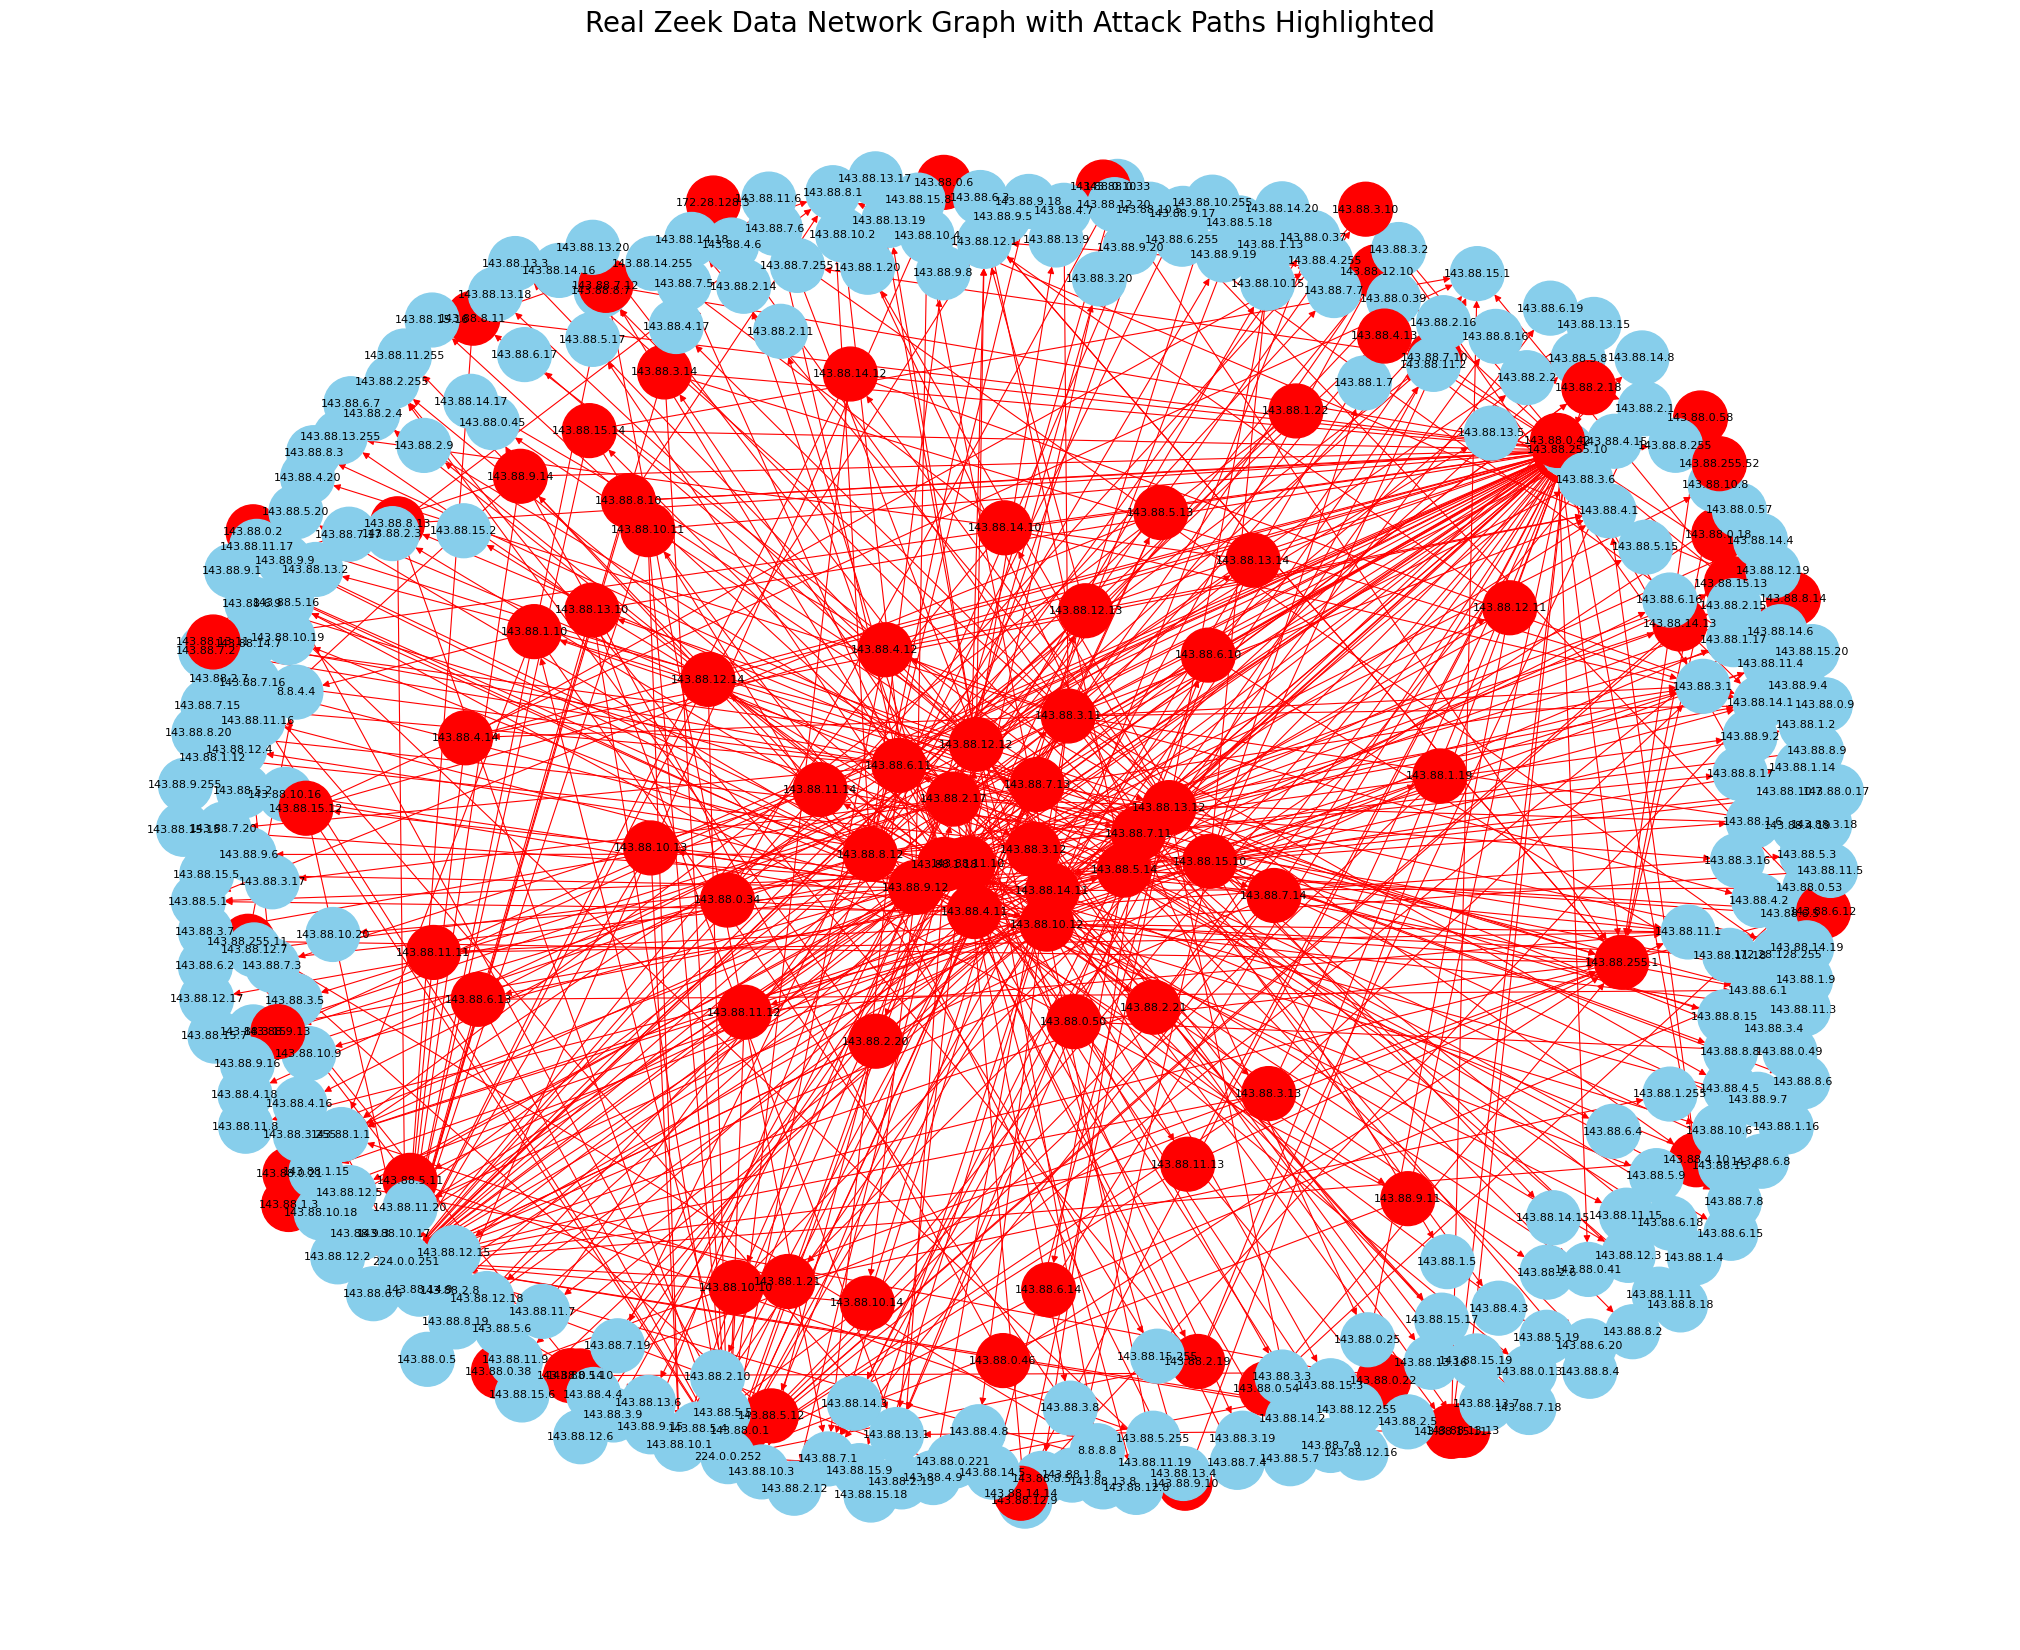

In [1]:
from thesis_analyzer import ThesisAnalyzer

analyzer = ThesisAnalyzer(
    uri="bolt://localhost:7687",
    user="neo4j",
    password="ubuntuubuntu",
    database="neo4j"  # Community Edition uses default database
)

# Build the database (downloads data and writes to Neo4j)
#analyzer.build_database(rebuild=True)

# Run analysis
analyzer.run_analysis()

In [ ]:
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

class KillChainAnalyzer:
    """
    Exploratory analysis of APT kill chain patterns in network data.
    Identifies nodes that transition from victim to attacker (lateral movement pivots).
    """
    
    def __init__(self, uri, user, password, database="neo4j"):
        self.uri = uri
        self.user = user
        self.password = password
        self.database = database
        self.driver = None
    
    def connect(self):
        """Connect to Neo4j."""
        self.driver = GraphDatabase.driver(self.uri, auth=(self.user, self.password))
        self.driver.verify_connectivity()
        print("✓ Connected to Neo4j")
    
    def close(self):
        """Close Neo4j connection."""
        if self.driver:
            self.driver.close()
            print("✓ Connection closed")
    
    def run_full_analysis(self):
        """Run complete exploratory analysis."""
        try:
            self.connect()
            
            print("\n" + "="*70)
            print("KILL CHAIN EXPLORATORY ANALYSIS")
            print("="*70)
            
            # Basic statistics
            self.get_basic_stats()
            
            # Find pivot nodes (victim -> attacker transitions)
            pivot_df = self.find_pivot_nodes()
            
            # Analyze pivot characteristics
            if pivot_df is not None and len(pivot_df) > 0:
                self.analyze_pivot_timing(pivot_df)
                self.analyze_pivot_tactics(pivot_df)
                self.analyze_attack_chains(pivot_df)
                self.visualize_pivot_patterns(pivot_df)
            else:
                print("\n⚠ No pivot nodes found in the data")
            
            print("\n" + "="*70)
            print("ANALYSIS COMPLETE")
            print("="*70)
            
        finally:
            self.close()
    
    def get_basic_stats(self):
        """Get basic statistics about the network and attacks."""
        print("\n--- BASIC STATISTICS ---")
        
        with self.driver.session(database=self.database) as session:
            # Total nodes and edges
            result = session.run("MATCH (n:IP) RETURN count(n) as node_count")
            node_count = result.single()["node_count"]
            
            result = session.run("MATCH ()-[r:CONNECTS]->() RETURN count(r) as edge_count")
            edge_count = result.single()["edge_count"]
            
            # Attack statistics
            result = session.run("MATCH ()-[r:CONNECTS]->() WHERE r.is_attack = 1 RETURN count(r) as attack_count")
            attack_count = result.single()["attack_count"]
            
            # Unique attackers and victims
            result = session.run("""
                MATCH (a:IP)-[r:CONNECTS]->(v:IP) 
                WHERE r.is_attack = 1 
                RETURN count(DISTINCT a) as attacker_count, count(DISTINCT v) as victim_count
            """)
            row = result.single()
            attacker_count = row["attacker_count"]
            victim_count = row["victim_count"]
            
            print(f"  Total IPs: {node_count:,}")
            print(f"  Total Connections: {edge_count:,}")
            print(f"  Attack Connections: {attack_count:,} ({attack_count/edge_count*100:.1f}%)")
            print(f"  Unique Attackers: {attacker_count:,}")
            print(f"  Unique Victims: {victim_count:,}")
            
            # Tactic distribution
            result = session.run("""
                MATCH ()-[r:CONNECTS]->() 
                WHERE r.is_attack = 1 AND r.tactic <> 'none'
                RETURN r.tactic as tactic, count(*) as count 
                ORDER BY count DESC
            """)
            
            print("\n  Attack Tactics Distribution:")
            for record in result:
                print(f"    {record['tactic']}: {record['count']:,}")
    
    def find_pivot_nodes(self):
        """Find nodes that were victims and later became attackers (lateral movement pivots)."""
        print("\n--- FINDING PIVOT NODES (Victim → Attacker Transitions) ---")
        
        with self.driver.session(database=self.database) as session:
            query = """
            // Find nodes that received attacks
            MATCH (attacker:IP)-[r1:CONNECTS]->(pivot:IP)
            WHERE r1.is_attack = 1
            
            // And later sent attacks
            MATCH (pivot)-[r2:CONNECTS]->(victim:IP)
            WHERE r2.is_attack = 1
            AND r2.timestamp > r1.timestamp  // Happened AFTER being attacked
            AND pivot <> attacker  // Pivot is different from original attacker
            AND victim <> attacker  // Not attacking back to original attacker
            
            RETURN DISTINCT
                pivot.address as pivot_ip,
                attacker.address as initial_attacker,
                victim.address as subsequent_victim,
                r1.timestamp as compromised_time,
                r2.timestamp as attack_time,
                (r2.timestamp - r1.timestamp) as time_to_attack,
                r1.tactic as compromise_tactic,
                r2.tactic as attack_tactic,
                r1.port as compromise_port,
                r2.port as attack_port
            ORDER BY r1.timestamp
            """
            
            result = session.run(query)
            records = [dict(record) for record in result]
            
            if not records:
                print("  ⚠ No pivot nodes found")
                return None
            
            df = pd.DataFrame(records)
            
            # Convert time_to_attack to hours
            df['hours_to_attack'] = df['time_to_attack'] / 3600
            
            print(f"  ✓ Found {len(df):,} pivot instances")
            print(f"  ✓ Unique pivot IPs: {df['pivot_ip'].nunique():,}")
            
            return df
    
    def analyze_pivot_timing(self, pivot_df):
        """Analyze timing between compromise and subsequent attack."""
        print("\n--- PIVOT TIMING ANALYSIS ---")
        
        print(f"  Time Between Compromise and Attack:")
        print(f"    Mean: {pivot_df['hours_to_attack'].mean():.2f} hours")
        print(f"    Median: {pivot_df['hours_to_attack'].median():.2f} hours")
        print(f"    Min: {pivot_df['hours_to_attack'].min():.2f} hours")
        print(f"    Max: {pivot_df['hours_to_attack'].max():.2f} hours")
        
        # How many within 24 hours?
        within_24h = (pivot_df['hours_to_attack'] <= 24).sum()
        within_48h = (pivot_df['hours_to_attack'] <= 48).sum()
        within_1w = (pivot_df['hours_to_attack'] <= 168).sum()
        
        total = len(pivot_df)
        print(f"\n  Pivot Attack Timeline:")
        print(f"    Within 24 hours: {within_24h:,} ({within_24h/total*100:.1f}%)")
        print(f"    Within 48 hours: {within_48h:,} ({within_48h/total*100:.1f}%)")
        print(f"    Within 1 week: {within_1w:,} ({within_1w/total*100:.1f}%)")
    
    def analyze_pivot_tactics(self, pivot_df):
        """Analyze what tactics are used for compromise vs subsequent attacks."""
        print("\n--- PIVOT TACTIC ANALYSIS ---")
        
        print("  Most Common Compromise Tactics:")
        compromise_tactics = pivot_df['compromise_tactic'].value_counts().head(10)
        for tactic, count in compromise_tactics.items():
            print(f"    {tactic}: {count:,}")
        
        print("\n  Most Common Attack Tactics (After Compromise):")
        attack_tactics = pivot_df['attack_tactic'].value_counts().head(10)
        for tactic, count in attack_tactics.items():
            print(f"    {tactic}: {count:,}")
        
        # Tactic transitions
        print("\n  Most Common Tactic Transitions:")
        transitions = pivot_df.groupby(['compromise_tactic', 'attack_tactic']).size().sort_values(ascending=False).head(10)
        for (comp, attack), count in transitions.items():
            print(f"    {comp} → {attack}: {count:,}")
    
    def analyze_attack_chains(self, pivot_df):
        """Analyze multi-hop attack chains (A→B→C→D...)."""
        print("\n--- ATTACK CHAIN ANALYSIS ---")
        
        with self.driver.session(database=self.database) as session:
            # Find chains of length 3+ (A→B→C)
            query = """
            MATCH path = (a:IP)-[r1:CONNECTS]->(b:IP)-[r2:CONNECTS]->(c:IP)-[r3:CONNECTS]->(d:IP)
            WHERE r1.is_attack = 1 AND r2.is_attack = 1 AND r3.is_attack = 1
            AND r2.timestamp > r1.timestamp
            AND r3.timestamp > r2.timestamp
            RETURN 
                a.address as hop1,
                b.address as hop2, 
                c.address as hop3,
                d.address as hop4,
                r1.timestamp as t1,
                r2.timestamp as t2,
                r3.timestamp as t3
            LIMIT 100
            """
            
            result = session.run(query)
            chains = [dict(record) for record in result]
            
            if chains:
                print(f"  ✓ Found {len(chains):,} attack chains (3+ hops)")
                
                # Show example chain
                if chains:
                    chain = chains[0]
                    print(f"\n  Example Attack Chain:")
                    print(f"    {chain['hop1']} → {chain['hop2']} → {chain['hop3']} → {chain['hop4']}")
                    
                    t1 = chain['t1']
                    t2 = chain['t2']
                    t3 = chain['t3']
                    print(f"    Timing: 0h → {(t2-t1)/3600:.1f}h → {(t3-t1)/3600:.1f}h")
            else:
                print("  No multi-hop chains found (or chains are rare)")
    
    def visualize_pivot_patterns(self, pivot_df):
        """Create visualizations of pivot patterns."""
        print("\n--- GENERATING VISUALIZATIONS ---")
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Time to attack histogram
        ax = axes[0, 0]
        pivot_df[pivot_df['hours_to_attack'] <= 168]['hours_to_attack'].hist(bins=50, ax=ax, edgecolor='black')
        ax.axvline(24, color='red', linestyle='--', label='24 hours')
        ax.set_xlabel('Hours Between Compromise and Attack')
        ax.set_ylabel('Frequency')
        ax.set_title('Distribution of Time to Pivot Attack (≤1 week)')
        ax.legend()
        
        # 2. Compromise tactics
        ax = axes[0, 1]
        top_comp = pivot_df['compromise_tactic'].value_counts().head(10)
        top_comp.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_xlabel('Count')
        ax.set_title('Top 10 Compromise Tactics')
        
        # 3. Attack tactics
        ax = axes[1, 0]
        top_attack = pivot_df['attack_tactic'].value_counts().head(10)
        top_attack.plot(kind='barh', ax=ax, color='coral')
        ax.set_xlabel('Count')
        ax.set_title('Top 10 Subsequent Attack Tactics')
        
        # 4. Pivot IPs - how many times did each pivot?
        ax = axes[1, 1]
        pivot_counts = pivot_df['pivot_ip'].value_counts().head(20)
        pivot_counts.plot(kind='bar', ax=ax, color='darkgreen')
        ax.set_xlabel('Pivot IP (top 20)')
        ax.set_ylabel('Number of Times Used as Pivot')
        ax.set_title('Most Frequently Used Pivot IPs')
        ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig('killchain_analysis.png', dpi=150, bbox_inches='tight')
        print("  ✓ Saved visualizations to 'killchain_analysis.png'")
        
        # Save pivot data to CSV for further analysis
        pivot_df.to_csv('pivot_nodes.csv', index=False)
        print("  ✓ Saved pivot node data to 'pivot_nodes.csv'")


# Usage
if __name__ == "__main__":
    analyzer = KillChainAnalyzer(
        uri="bolt://localhost:7687",
        user="neo4j",
        password="ubuntuubuntu"
    )
    
    analyzer.run_full_analysis()

✓ Connected to Neo4j

KILL CHAIN EXPLORATORY ANALYSIS

--- BASIC STATISTICS ---
  Total IPs: 357
  Total Connections: 1,898,613
  Attack Connections: 1,898,613 (100.0%)
  Unique Attackers: 95
  Unique Victims: 342

  Attack Tactics Distribution:
    Credential Access: 871,188
    Reconnaissance: 58,095
    Defense Evasion: 6,048
    Initial Access: 4,614
    Exfiltration: 559

--- FINDING PIVOT NODES (Victim → Attacker Transitions) ---
